<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bubble Plots**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be directly loaded into pandas for analysis and visualization.

You will use various visualization techniques to explore the data and uncover key trends.


## Objectives


In this lab, you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two data features.

-   Visualize composition of data.

-   Visualize comparison of data.


#### Setup: Working with the Database
**Install and import the needed libraries**


In [1]:
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [3]:
# Step 1: Download the dataset
#!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Load the data
#df = pd.read_csv("survey-data.csv")

# Display the first few rows of the data to understand its structure
#df.head()


In [4]:
import requests

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
filename = "survey-data.csv"

response = requests.get(url)

with open(filename, "wb") as f:
    f.write(response.content)

df = pd.read_csv(filename)

df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Exploring Data Distributions Using Bubble Plots


#### 1. Bubble Plot for Age vs. Frequency of Participation


- Visualize the relationship between respondents’ age and their participation frequency (`SOPartFreq`) using a bubble plot.

- Use the size of the bubbles to represent their job satisfaction (`JobSat`).


In [27]:
## Inspection first

print("Distribution of variables:\n", df[['Age', 'SOPartFreq', 'JobSat']].describe(include="all"))
print()
print("Value counts of variables:\n", df[['Age', 'SOPartFreq', 'JobSat']].value_counts(dropna=False))
print()
print("Unique variables categories:\n", df[['Age', 'SOPartFreq', 'JobSat']].nunique())

Distribution of variables:
                     Age                           SOPartFreq        JobSat
count             65437                                45237  29126.000000
unique                8                                    6           NaN
top     25-34 years old  Less than once per month or monthly           NaN
freq              23911                                24162           NaN
mean                NaN                                  NaN      6.935041
std                 NaN                                  NaN      2.088259
min                 NaN                                  NaN      0.000000
25%                 NaN                                  NaN      6.000000
50%                 NaN                                  NaN      7.000000
75%                 NaN                                  NaN      8.000000
max                 NaN                                  NaN     10.000000

Value counts of variables:
 Age                 SOPartFreq             

In [22]:
age_map = {
    'Under 18 years old': 17.0,
    '18-24 years old': 21.0,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70.0
}

df['Age_num'] = df['Age'].map(age_map)

In [23]:
freq_map = {
    "Multiple times per day": 5,
    "Daily or almost daily": 4,
    "A few times per week": 3,
    "A few times per month or weekly": 2,
    "Less than once per month or monthly": 1,
    "I have never participated in Q&A on Stack Overflow": 0
}

df['SOPartFreq_num'] = df['SOPartFreq'].map(freq_map)

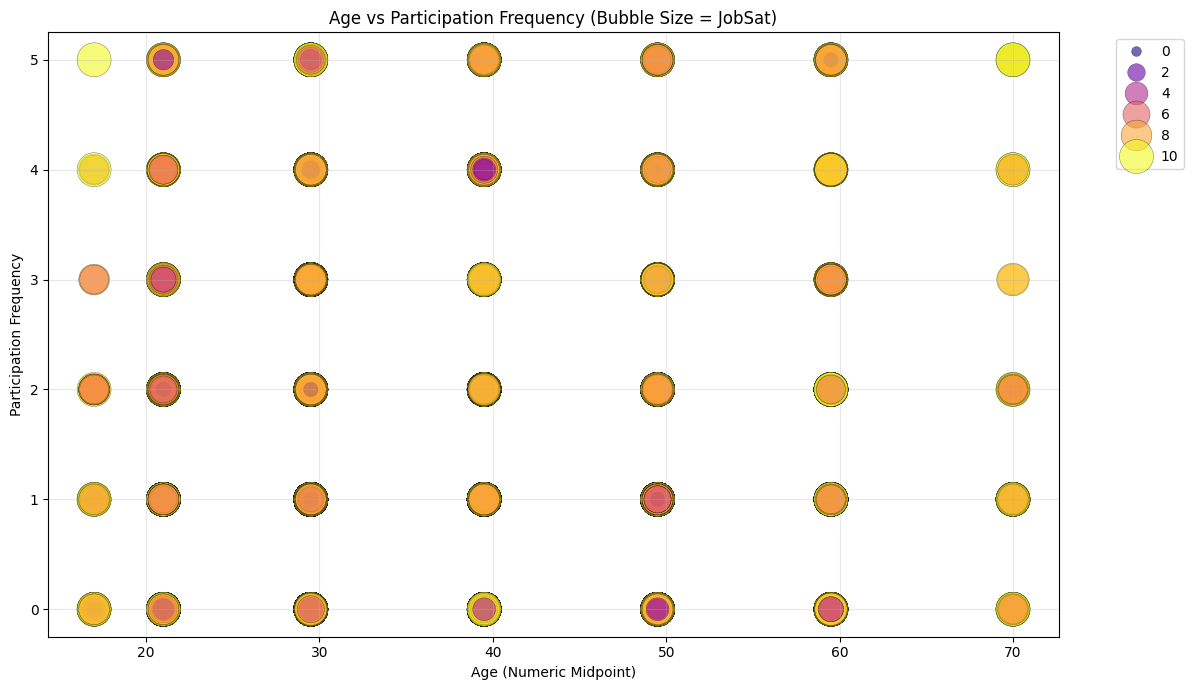

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,7))

sns.scatterplot(
    data=df,
    x='Age_num',
    y='SOPartFreq_num',
    hue='JobSat',
    size='JobSat',
    palette='plasma',
    sizes=(50, 600),
    alpha=0.6,
    edgecolor='black',
    linewidth=0.3
)

plt.title('Age vs Participation Frequency (Bubble Size = JobSat)')
plt.xlabel('Age (Numeric Midpoint)')
plt.ylabel('Participation Frequency')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Compensation vs. Job Satisfaction


-Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSat`).

- Use the size of the bubbles to represent respondents’ age.


In [32]:
##Write your code here

# Deal with outliers in converted comp yearly

comp = df['ConvertedCompYearly']

Q1 = comp.quantile(0.25)
Q3 = comp.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['ConvertedCompYearly_clean'] = df['ConvertedCompYearly'].where(
    (df['ConvertedCompYearly'] >= lower) &
    (df['ConvertedCompYearly'] <= upper)
)

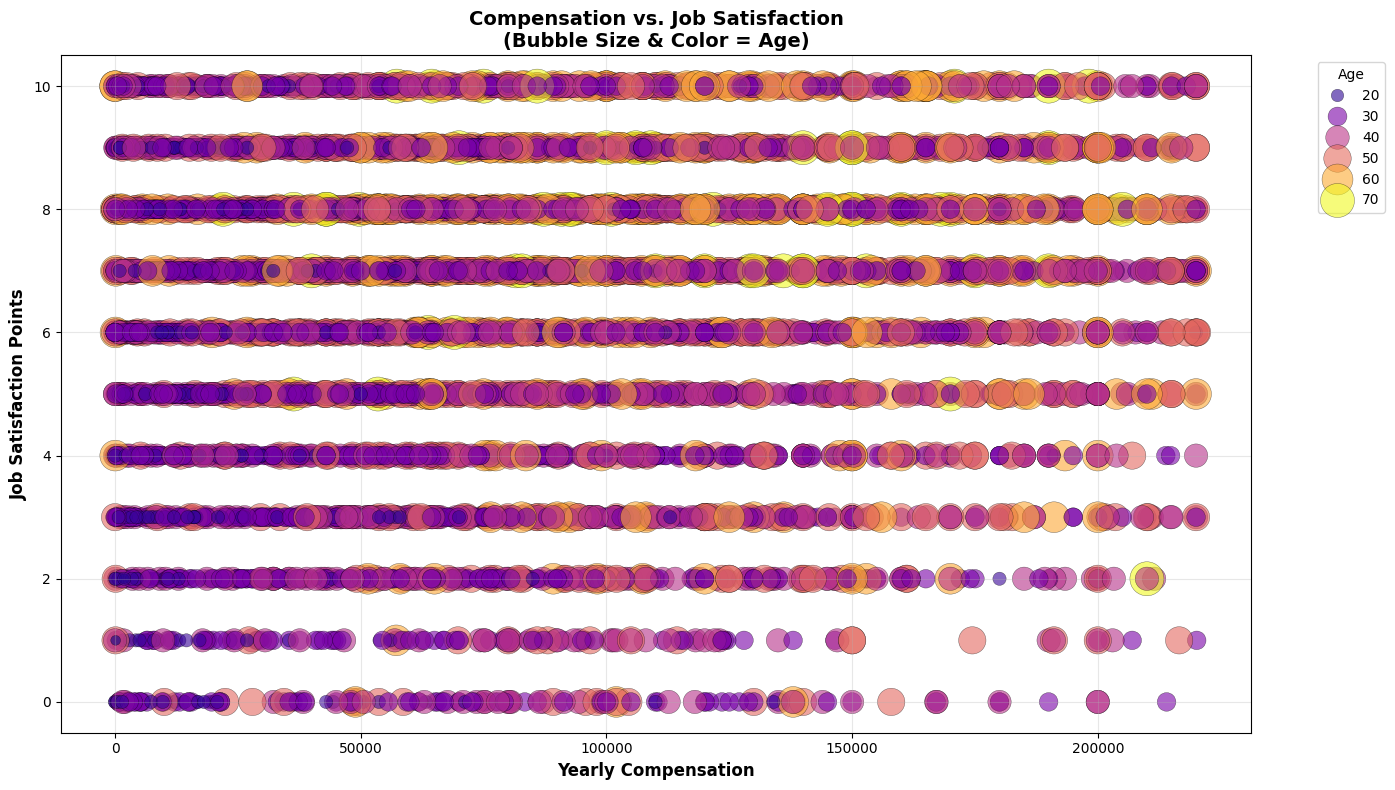

In [34]:
## Write your code here

# Remove NaN values
bubble_data = df[['ConvertedCompYearly_clean', 'JobSat', 'Age_num']].dropna()

plt.figure(figsize=(14, 8))
sns.scatterplot(data=bubble_data, 
                x='ConvertedCompYearly_clean', 
                y='JobSat',
                size='Age_num',
                hue='Age_num',
                palette='plasma',
                sizes=(50, 600),
                alpha=0.6,
                edgecolor='black',
                linewidth=0.3)
plt.xlabel('Yearly Compensation', fontsize=12, fontweight='bold')
plt.ylabel('Job Satisfaction Points', fontsize=12, fontweight='bold')
plt.title('Compensation vs. Job Satisfaction\n(Bubble Size & Color = Age)', 
          fontsize=14, fontweight='bold')
plt.legend(title='Age', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Task 2: Analyzing Relationships Using Bubble Plots


#### 1. Bubble Plot of Technology Preferences by Age

- Visualize the popularity of programming languages respondents have worked with (`LanguageHaveWorkedWith`) across age groups.

- Use bubble size to represent the frequency of each language.



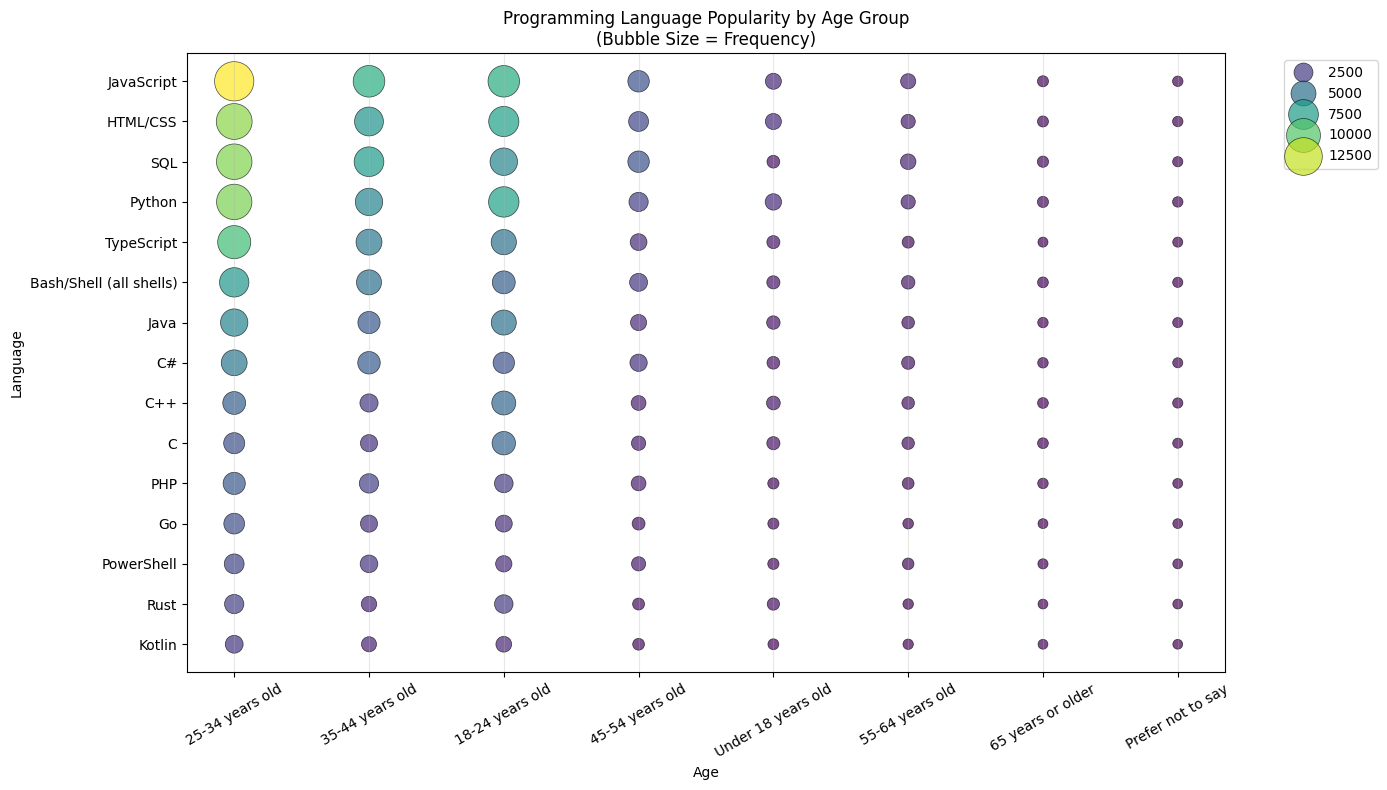

In [37]:
##Write your code here

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# EXPLODE + CLEAN + BUILD TABLE
lang_age_counts = (
    df[['Age', 'LanguageHaveWorkedWith']]
    .dropna()
    .assign(Language=lambda x: x['LanguageHaveWorkedWith'].str.split(';'))
    .explode('Language')
    .assign(Language=lambda x: x['Language'].str.strip())
    .groupby(['Age', 'Language'])
    .size()
    .reset_index(name='count')
)

# KEEP TOP LANGUAGES
top_langs = lang_age_counts.groupby('Language')['count'].sum().nlargest(15).index
lang_age_counts = lang_age_counts[lang_age_counts['Language'].isin(top_langs)]
lang_age_counts = lang_age_counts.sort_values('count', ascending=False)

# PLOT
plt.figure(figsize=(14,8))

sns.scatterplot(
    data=lang_age_counts,
    x='Age',
    y='Language',
    size='count',
    hue='count',
    palette='viridis',
    sizes=(50, 800),
    alpha=0.7,
    edgecolor='black',
    linewidth=0.5
)

plt.title('Programming Language Popularity by Age Group\n(Bubble Size = Frequency)')
plt.xticks(rotation=30)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Preferred Databases vs. Job Satisfaction

- Explore the relationship between preferred databases (`DatabaseWantToWorkWith`) and job satisfaction.

- Use bubble size to indicate the number of respondents for each database.


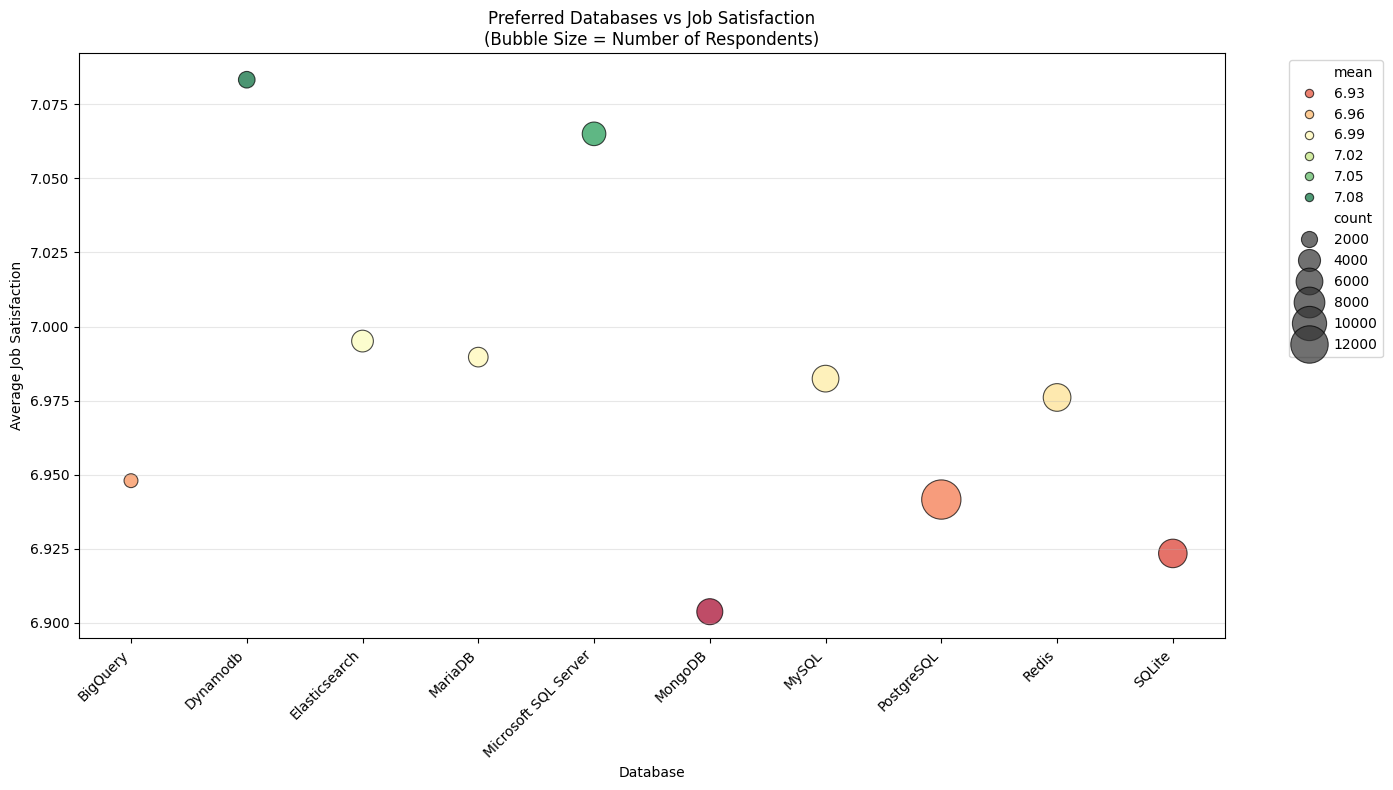

In [38]:
##Write your code here

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------
# STEP 1: EXPLODE DATABASES (your cleaned logic)
# --------------------------------------------------
db_df = (
    df[['DatabaseWantToWorkWith', 'JobSat']]
    .dropna()
    .assign(Database=lambda x: x['DatabaseWantToWorkWith'].str.split(';'))
    .explode('Database')
    .assign(Database=lambda x: x['Database'].str.strip())
)

# Remove invalid placeholder values
db_df = db_df[db_df['Database'] != 'None']

# --------------------------------------------------
# STEP 2: KEEP TOP DATABASES (by popularity)
# --------------------------------------------------
top_db = db_df['Database'].value_counts().head(10).index
db_df = db_df[db_df['Database'].isin(top_db)]

# --------------------------------------------------
# STEP 3: AGGREGATE (mean + count like reference code)
# --------------------------------------------------
db_summary = (
    db_df.groupby('Database')['JobSat']
    .agg(['mean', 'count'])
    .reset_index()
)

# --------------------------------------------------
# STEP 4: BUBBLE PLOT
# --------------------------------------------------
plt.figure(figsize=(14,8))

sns.scatterplot(
    data=db_summary,
    x='Database',
    y='mean',
    size='count',
    hue='mean',
    palette='RdYlGn',
    sizes=(100, 800),
    alpha=0.7,
    edgecolor='black',
    linewidth=0.8
)

plt.title('Preferred Databases vs Job Satisfaction\n(Bubble Size = Number of Respondents)')
plt.xlabel('Database')
plt.ylabel('Average Job Satisfaction')

plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Task 3: Comparing Data Using Bubble Plots


#### 1. Bubble Plot for Compensation Across Developer Roles

- Visualize compensation (`ConvertedCompYearly`) across different developer roles (`DevType`).

- Use bubble size to represent job satisfaction.


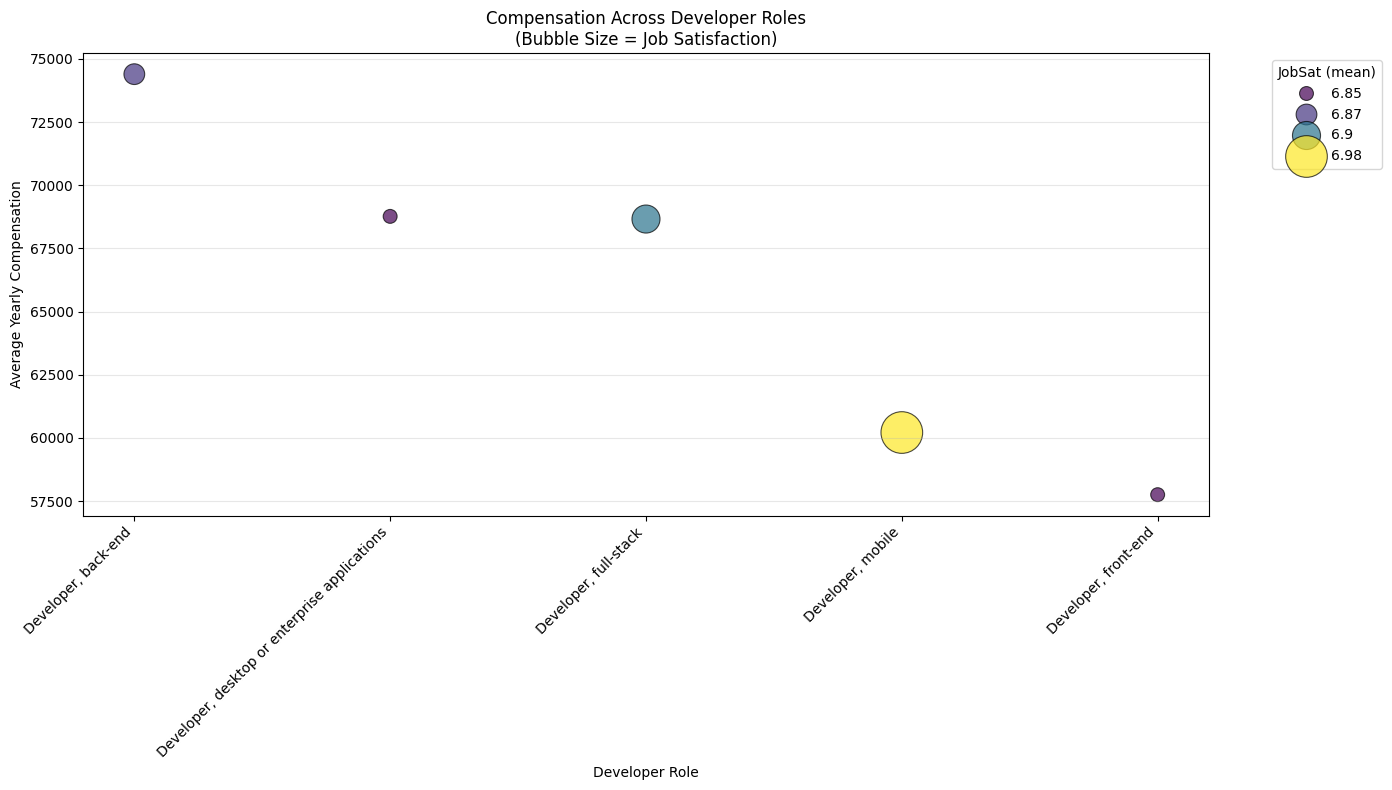

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------
# STEP 1: CLEAN + EXPLODE
# --------------------------------------------------
dev_df = (
    df[['DevType', 'ConvertedCompYearly_clean', 'JobSat']]
    .dropna()
    .assign(DevType=lambda x: x['DevType'].str.split(';'))
    .explode('DevType')
    .assign(DevType=lambda x: x['DevType'].str.strip())
)

# --------------------------------------------------
# STEP 2: TOP 5 ROLES
# --------------------------------------------------
top_roles = dev_df['DevType'].value_counts().head(5).index
dev_df = dev_df[dev_df['DevType'].isin(top_roles)]

# --------------------------------------------------
# STEP 3: AGGREGATE (MEAN + COUNT)
# --------------------------------------------------
dev_summary = (
    dev_df.groupby('DevType')
    .agg(
        mean_comp=('ConvertedCompYearly_clean', 'mean'),
        mean_sat=('JobSat', 'mean'),
        count=('JobSat', 'count')
    )
    .reset_index()
)

# --------------------------------------------------
# STEP 4: SORT BY COMPENSATION (DESCENDING)
# --------------------------------------------------
dev_summary = dev_summary.sort_values('mean_comp', ascending=False)

# round for clean legend
dev_summary['mean_sat'] = dev_summary['mean_sat'].round(2)

# --------------------------------------------------
# STEP 5: PLOT
# --------------------------------------------------
plt.figure(figsize=(14,8))

sns.scatterplot(
    data=dev_summary,
    x='DevType',
    y='mean_comp',
    size='mean_sat',      # bubble size = job satisfaction (as you want)
    hue='mean_sat',
    palette='viridis',
    sizes=(100, 900),
    alpha=0.7,
    edgecolor='black',
    linewidth=0.8
)

plt.title('Compensation Across Developer Roles\n(Bubble Size = Job Satisfaction)')
plt.xlabel('Developer Role')
plt.ylabel('Average Yearly Compensation')

plt.xticks(rotation=45, ha='right')

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    frameon=True,
    title='JobSat (mean)'
)

plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Collaboration Tools by Age

- Visualize the relationship between the collaboration tools used (`NEWCollabToolsHaveWorkedWith`) and age groups.

- Use bubble size to represent the frequency of tool usage.


In [46]:
##Write your code here

# Preview values
print("First 5 rows of NEWCollabToolsHaveWorkedWith:")
print(df['NEWCollabToolsHaveWorkedWith'].head())
print("\n")

# Value counts (top 10)
print("Top 10 most common collaboration tool combinations:")
print(df['NEWCollabToolsHaveWorkedWith'].value_counts().head(10))
print("\n")

# Number of unique responses
print("Number of unique responses:")
print(df['NEWCollabToolsHaveWorkedWith'].nunique())
print("\n")

# Basic descriptive statistics
print("Column description:")
print(df['NEWCollabToolsHaveWorkedWith'].describe(include="all"))

First 5 rows of NEWCollabToolsHaveWorkedWith:
0                                    NaN
1    PyCharm;Visual Studio Code;WebStorm
2                          Visual Studio
3                                    NaN
4                                    Vim
Name: NEWCollabToolsHaveWorkedWith, dtype: str


Top 10 most common collaboration tool combinations:
NEWCollabToolsHaveWorkedWith
Visual Studio Code                            6154
Visual Studio;Visual Studio Code              2546
Notepad++;Visual Studio;Visual Studio Code    1543
IntelliJ IDEA;Visual Studio Code              1169
Vim;Visual Studio Code                        1045
IntelliJ IDEA                                  794
Visual Studio                                  711
Neovim                                         666
Neovim;Visual Studio Code                      584
Notepad++;Visual Studio Code                   560
Name: count, dtype: int64


Number of unique responses:
14168


Column description:
count                  57

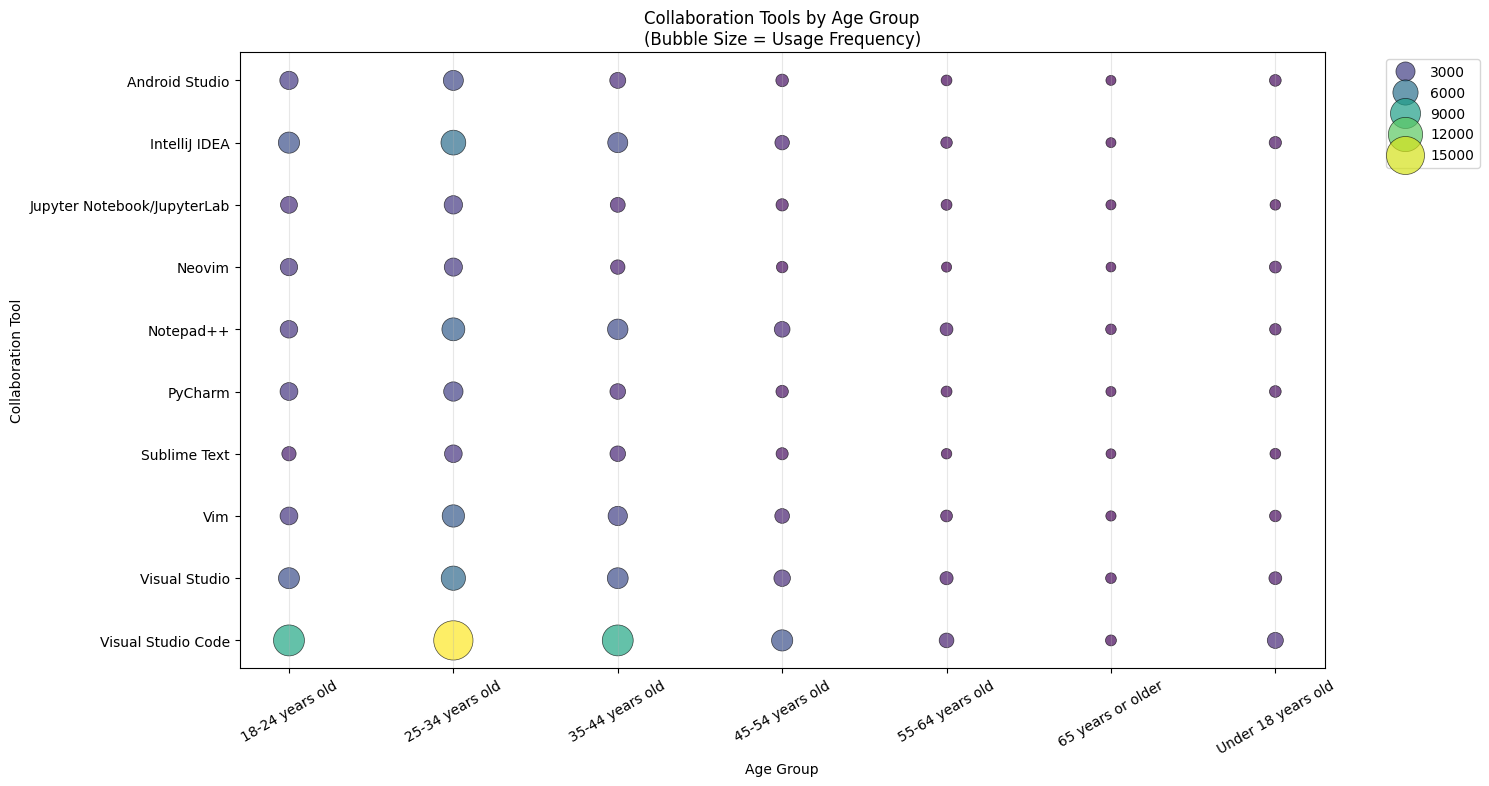

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------
# STEP 1: EXPLODE + CLEAN (multi-label column)
# --------------------------------------------------
tool_df = (
    df[['Age', 'NEWCollabToolsHaveWorkedWith']]
    .dropna()
    .assign(Tool=lambda x: x['NEWCollabToolsHaveWorkedWith'].str.split(';'))
    .explode('Tool')
    .assign(Tool=lambda x: x['Tool'].str.strip())
)

# --------------------------------------------------
# STEP 2: FREQUENCY (Age × Tool)
# --------------------------------------------------
tool_counts = (
    tool_df.groupby(['Age', 'Tool'])
    .size()
    .reset_index(name='count')
)

# --------------------------------------------------
# STEP 3: KEEP TOP 10 MOST USED TOOLS
# --------------------------------------------------
top_tools = tool_counts.groupby('Tool')['count'].sum().nlargest(10).index
tool_counts = tool_counts[tool_counts['Tool'].isin(top_tools)]
tool_counts = tool_counts[tool_counts['Age'] != 'Prefer not to say']

# --------------------------------------------------
# STEP 4: BUBBLE PLOT
# --------------------------------------------------
plt.figure(figsize=(14,8))

sns.scatterplot(
    data=tool_counts,
    x='Age',
    y='Tool',
    size='count',
    hue='count',
    palette='viridis',
    sizes=(50, 800),
    alpha=0.7,
    edgecolor='black',
    linewidth=0.5
)

plt.title('Collaboration Tools by Age Group\n(Bubble Size = Usage Frequency)')
plt.xlabel('Age Group')
plt.ylabel('Collaboration Tool')

plt.xticks(rotation=30)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3, axis='x')

#plt.tight_layout()
plt.show()

### Task 4: Visualizing Technology Trends Using Bubble Plots


#### 1. Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction

- Explore the relationship between preferred web frameworks (`WebframeWantToWorkWith`) and job satisfaction.

- Use bubble size to represent the number of respondents.



In [48]:
##Write your code here
# Value counts (top 10)
print("Top 10 most common WebframeWantToWorkWith:")
print(df['WebframeWantToWorkWith'].value_counts().head(10))
print("\n")

# Number of unique responses
print("Number of unique responses:")
print(df['WebframeWantToWorkWith'].nunique())
print("\n")

Top 10 most common WebframeWantToWorkWith:
WebframeWantToWorkWith
React                  997
Spring Boot            950
Node.js                619
ASP.NET CORE           607
FastAPI                576
Node.js;React          480
ASP.NET CORE;Blazor    465
Angular                432
Svelte                 416
Django                 413
Name: count, dtype: int64


Number of unique responses:
11654




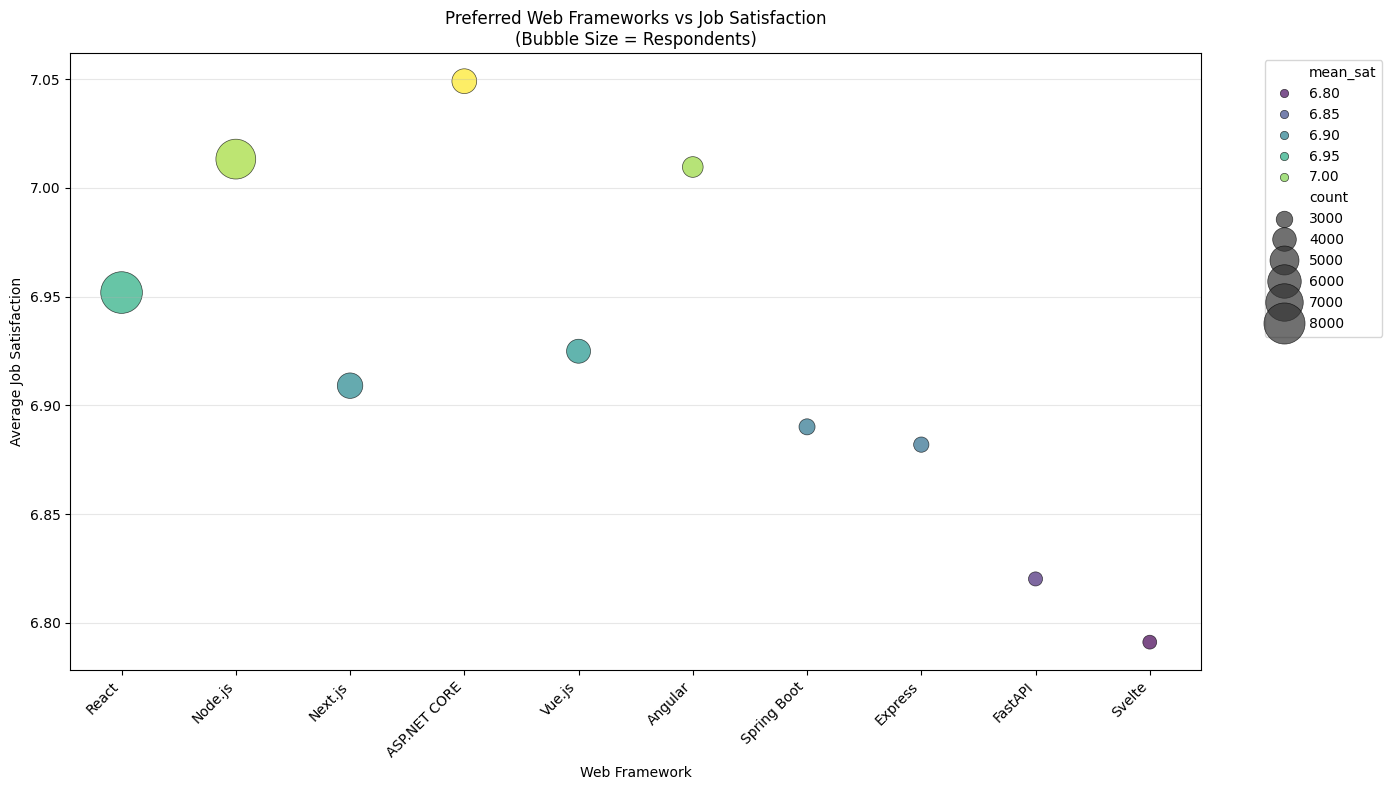

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------
# STEP 1: EXPLODE + CLEAN
# --------------------------------------------------
wf_df = (
    df[['WebframeWantToWorkWith', 'JobSat']]
    .dropna()
    .assign(Framework=lambda x: x['WebframeWantToWorkWith'].str.split(';'))
    .explode('Framework')
    .assign(Framework=lambda x: x['Framework'].str.strip())
)

# --------------------------------------------------
# STEP 2: FREQUENCY + SATISFACTION
# --------------------------------------------------
wf_summary = (
    wf_df.groupby('Framework')
    .agg(
        count=('JobSat', 'count'),
        mean_sat=('JobSat', 'mean')
    )
    .reset_index()
)

# --------------------------------------------------
# STEP 3: TOP 10 FRAMEWORKS
# --------------------------------------------------
wf_summary = wf_summary.sort_values('count', ascending=False).head(10)

# --------------------------------------------------
# STEP 4: PLOT
# --------------------------------------------------
plt.figure(figsize=(14,8))

sns.scatterplot(
    data=wf_summary,
    x='Framework',
    y='mean_sat',
    size='count',
    hue='mean_sat',
    palette='viridis',
    sizes=(100, 900),
    alpha=0.7,
    edgecolor='black',
    linewidth=0.5
)

plt.title('Preferred Web Frameworks vs Job Satisfaction\n(Bubble Size = Respondents)')
plt.xlabel('Web Framework')
plt.ylabel('Average Job Satisfaction')

plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Admired Technologies Across Countries

- Visualize the distribution of admired technologies (`LanguageAdmired`) across different countries (`Country`).

- Use bubble size to represent the frequency of admiration.



In [50]:
##Write your code here
##Write your code here
# Value counts (top 10)
print("Top 10 most common LanguageAdmired:")
print(df['LanguageAdmired'].value_counts().head(10))
print("\n")

# Number of unique responses
print("Number of unique responses:")
print(df['LanguageAdmired'].nunique())
print("\n")

Top 10 most common LanguageAdmired:
LanguageAdmired
Python                            1555
HTML/CSS;JavaScript;TypeScript    1058
C#                                 892
Python;SQL                         669
Java                               583
HTML/CSS;JavaScript                565
Rust                               543
JavaScript;TypeScript              477
C#;SQL                             465
Bash/Shell (all shells);Python     436
Name: count, dtype: int64


Number of unique responses:
12335




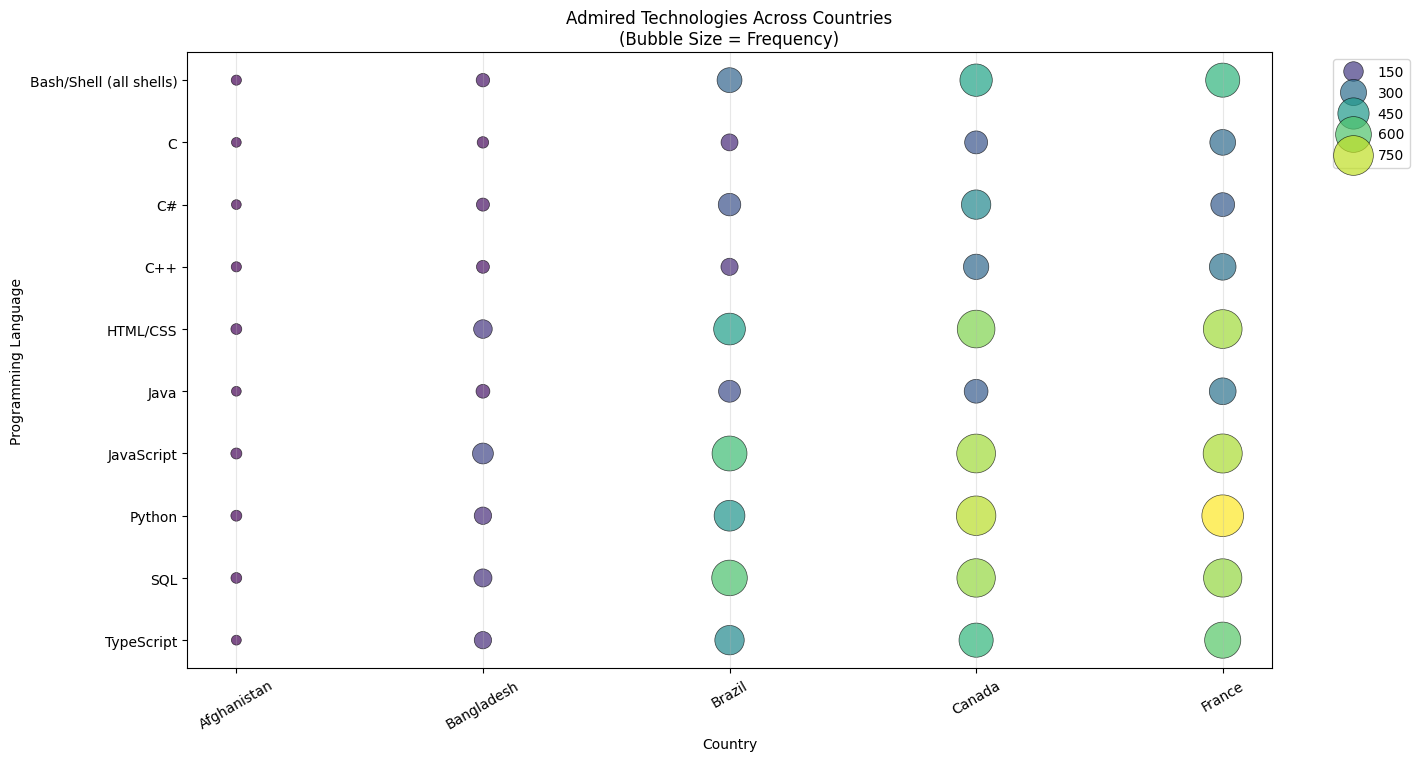

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------
# STEP 1: EXPLODE + CLEAN
# --------------------------------------------------
adm_df = (
    df[['Country', 'LanguageAdmired']]
    .dropna()
    .assign(Lang=lambda x: x['LanguageAdmired'].str.split(';'))
    .explode('Lang')
    .assign(Lang=lambda x: x['Lang'].str.strip())
)

# ✔ ADD COUNTRY SHORT (ONLY NEW LINE)
adm_df['Country_short'] = adm_df['Country'].apply(
    lambda x: " ".join(str(x).split()[:2])
)

# --------------------------------------------------
# STEP 2: FREQUENCY COUNT (Country × Language)
# --------------------------------------------------
adm_counts = (
    adm_df.groupby(['Country_short', 'Lang'])
    .size()
    .reset_index(name='count')
)

# --------------------------------------------------
# STEP 3: TOP COUNTRIES + TOP LANGUAGES
# --------------------------------------------------
top_countries = adm_counts['Country_short'].value_counts().head(5).index
adm_counts = adm_counts[adm_counts['Country_short'].isin(top_countries)]

top_langs = adm_counts.groupby('Lang')['count'].sum().nlargest(10).index
adm_counts = adm_counts[adm_counts['Lang'].isin(top_langs)]

# --------------------------------------------------
# STEP 4: PLOT
# --------------------------------------------------
plt.figure(figsize=(14,8))

sns.scatterplot(
    data=adm_counts,
    x='Country_short',
    y='Lang',
    size='count',
    hue='count',
    palette='viridis',
    sizes=(50, 900),
    alpha=0.7,
    edgecolor='black',
    linewidth=0.5
)

plt.title('Admired Technologies Across Countries\n(Bubble Size = Frequency)')
plt.xlabel('Country')
plt.ylabel('Programming Language')

plt.xticks(rotation=30)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3, axis='x')

#plt.tight_layout()
plt.show()

## Final Step: Review


After completing the lab, you will have extensively used bubble plots to gain insights into developer community preferences, demographics, compensation trends, and job satisfaction.


## Summary


After completing this lab, you will be able to:

- Create and interpret bubble plots to analyze relationships and compositions within datasets.

- Use bubble plots to explore developer preferences, compensation trends, and satisfaction levels.

- Apply bubble plots to visualize complex relationships involving multiple dimensions effectively.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-29|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
